# Exercise 1 — Notebook 4: Forecasting

## Purpose of this notebook

This notebook answers Task 1.3 of the exercise: use a simple forecasting 
method to project customer/portfolio behaviour 12 months forward.

We deliberately use **two simple, complementary methods** rather than one 
complex model.

1. **Markov-chain roll-rate projection** (primary method) — reuses the 
   transition matrix built in notebook 3 to project the portfolio's state 
   distribution, and therefore default rate, 12 months forward. This is 
   genuine, real-world credit risk methodology.
2. **Simple trend extrapolation** (secondary, cross-check method) — a basic 
   linear regression on the 12 monthly default rate observations, projected 
   forward with an honest confidence interval.

We then **reconcile** the two methods explicitly, stating whether they agree 
directionally, and close with an honest statement of the limitations of 
forecasting from only 12 data points.

## Step 1: Load the cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
df = pd.read_excel('data/cleaned_portfolio_data.xlsx')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Unique customers: {df['CustomerID'].nunique()}")

Shape: 12000 rows, 18 columns
Unique customers: 1000


---

## Method 1: Markov-chain roll-rate projection

This method reuses the transition matrix built in notebook 3. The logic: 
if we know the probability of moving from any given delinquency state to 
any other state in one month, and we assume these probabilities stay stable, 
we can apply them repeatedly to project the portfolio's state distribution 
forward as many months as we like.

**Step-by-step approach:**
1. Rebuild the transition matrix (same logic as notebook 3, so this notebook 
   is self-contained)
2. Take the portfolio's **current** state distribution (as of the last 
   observed month, September 2023)
3. Multiply that distribution by the transition matrix, repeatedly, 12 times
4. Read off the projected % of the portfolio in the "4+ (Default)" state 
   after 12 iterations — this is our projected default rate 12 months 
   from now

In [2]:
# Rebuild transition matrix exactly as in notebook 3
df_sorted=df.sort_values(['CustomerID', 'ForDate']).copy()
df_sorted['next_state']=df_sorted.groupby('CustomerID')['MonthsPastDue_label'].shift(-1)
transitions=df_sorted.dropna(subset=['next_state'])
transition_matrix = pd.crosstab(
    transitions['MonthsPastDue_label'], 
    transitions['next_state'], 
    normalize='index')

state_order=['0', '1', '2', '3', '4+ (Default)']
transition_matrix=transition_matrix.reindex(index=state_order,columns=state_order).fillna(0)
print("Transition matrix (rebuilt):")
print((transition_matrix*100).round(1))

Transition matrix (rebuilt):
next_state              0    1     2     3  4+ (Default)
MonthsPastDue_label                                     
0                    94.0  6.0   0.0   0.0           0.0
1                    61.6  8.6  29.9   0.0           0.0
2                    29.6  6.1   4.2  59.6           0.5
3                    17.3  2.2   2.2   2.9          75.5
4+ (Default)          0.5  0.0   0.2   0.0          99.4


### Current portfolio state distribution

We take the portfolio's state distribution as of the **last observed month** 
(September 2023) as our starting point for the projection — this represents 
"where the portfolio stands today."

In [3]:
latest_month=df['ForDate'].max()
current_state_counts=df[df['ForDate']==latest_month]['MonthsPastDue_label'].value_counts()
current_state_distribution=(current_state_counts/current_state_counts.sum()).reindex(state_order).fillna(0)
print(f"Portfolio state distribution as of {latest_month.strftime('%B %Y')}:")
print((current_state_distribution*100).round(2))

Portfolio state distribution as of September 2023:
MonthsPastDue_label
0               82.6
1                4.9
2                1.5
3                0.8
4+ (Default)    10.2
Name: count, dtype: float64


### Projecting forward 12 months

We apply the transition matrix iteratively: each month's distribution is 
the previous month's distribution multiplied by the transition matrix. We 
store every intermediate month so we can plot the full projected trajectory, 
not just the final 12-month figure.

In [4]:
# Convert to numpy for matrix multiplication
T=transition_matrix.values
state=current_state_distribution.values.copy()
projection_months=12
projected_states=[state.copy()]
for month in range(projection_months):
    state=state @ T   #we apply the transition matrix one more month
    projected_states.append(state.copy())

projected_df=pd.DataFrame(projected_states,columns=state_order)
projected_df.index.name='months_ahead'
print("Projected portfolio state distribution, month by month (%):")
print((projected_df * 100).round(2))


Projected portfolio state distribution, month by month (%):
                  0     1     2     3  4+ (Default)
months_ahead                                       
0             82.60  4.90  1.50  0.80         10.20
1             81.25  5.52  1.56  0.92         10.75
2             80.41  5.50  1.75  0.96         11.38
3             79.67  5.46  1.76  1.07         12.04
4             78.98  5.42  1.75  1.08         12.78
5             78.30  5.37  1.73  1.07         13.52
6             77.64  5.32  1.72  1.07         14.25
7             76.98  5.28  1.71  1.06         14.98
8             76.33  5.23  1.69  1.05         15.69
9             75.70  5.19  1.68  1.04         16.39
10            75.07  5.15  1.67  1.03         17.08
11            74.45  5.10  1.66  1.02         17.76
12            73.85  5.06  1.64  1.02         18.43


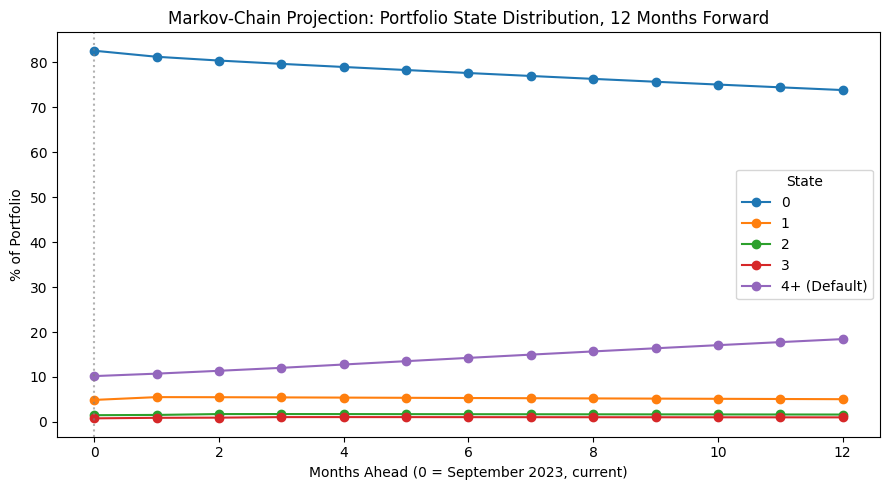


Projected default rate ('4+') 12 months from now: 18.43%
Current default rate (September 2023): 10.20%


In [5]:
plt.figure(figsize=(9, 5))
for state_name in state_order:
    plt.plot(projected_df.index,projected_df[state_name]*100,marker='o',label=state_name)

plt.axvline(0,color='gray',linestyle=':',alpha=0.6)
plt.xlabel('Months Ahead (0 = September 2023, current)')
plt.ylabel('% of Portfolio')
plt.title('Markov-Chain Projection: Portfolio State Distribution, 12 Months Forward')
plt.legend(title='State')
plt.tight_layout()
plt.savefig('figures/markov_projection_states.png', dpi=150)
plt.show()
print(f"\nProjected default rate ('4+') 12 months from now: {projected_df['4+ (Default)'].iloc[-1]*100:.2f}%")
print(f"Current default rate (September 2023): {current_state_distribution['4+ (Default)']*100:.2f}%")

**Interpretation**

This forecast shows that the default rate will nearly double over the next 12 months, jumping from 10% to 18%. The real value of this finding isn't just the higher number—it is that we know exactly what is causing it. The problem is a weak "cure rate," meaning very few customers manage to get back on track once they fall 2 months behind on their payments. This tells management exactly where to focus. Instead of spreading our collection efforts everywhere, the smartest move is to target customers the moment they hit that 2-month late mark, because that is the exact point where they usually fail to recover. Finally, if an 18% default rate is higher than the bank is safely willing to accept, this warning should prompt us to tighten our lending rules for this group right now, well before the problem actually gets that bad.

---

## Method 2: Simple trend extrapolation (cross-check)

As a second, independent method, we fit a basic linear regression to the 
12 monthly default rate observations and extrapolate forward 12 months, 
with a confidence interval. its purpose here is 
not to be more sophisticated than Method 1, but to provide an independent 
check using a completely different mechanism (statistical trend-fitting 
rather than transition probabilities).

**Important honesty point:** with only 12 monthly data points, any 
statistical forecast carries substantial uncertainty. We state this 
explicitly rather than presenting a false sense of precision.

In [6]:
monthly_default=df.groupby('ForDate').agg(total_customers=('CustomerID', 'nunique'),defaulted_customers=('is_default', 'sum')).reset_index()
monthly_default['monthly_default_rate_pct']=(monthly_default['defaulted_customers']/monthly_default['total_customers'] * 100)
monthly_default['month_index']=range(len(monthly_default))
print(monthly_default[['ForDate','monthly_default_rate_pct','month_index']])

      ForDate  monthly_default_rate_pct  month_index
0  2022-10-01                       0.0            0
1  2022-11-01                       1.6            1
2  2022-12-01                       2.8            2
3  2023-01-01                       4.2            3
4  2023-02-01                       5.5            4
5  2023-03-01                       6.4            5
6  2023-04-01                       7.0            6
7  2023-05-01                       8.0            7
8  2023-06-01                       8.8            8
9  2023-07-01                       9.0            9
10 2023-08-01                      10.0           10
11 2023-09-01                      10.2           11


In [7]:
x=monthly_default['month_index'].values
y=monthly_default['monthly_default_rate_pct'].values
slope,intercept,r_value,p_value,std_err=stats.linregress(x,y)
print(f"Slope: {slope:.4f}% per month")
print(f"Intercept: {intercept:.4f}%")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.6f}")
#Project forward 12 more months (month indices 12 through 23)
future_x=np.arange(len(monthly_default),len(monthly_default)+12)
future_y=intercept + slope * future_x
#Simple confidence interval using the standard error of the regression
n=len(x)
residuals=y-(intercept+slope*x)
residual_std=np.std(residuals, ddof=2)
ci_margin=1.96*residual_std   # approximate 95% CI band
print(f"\nProjected default rate 12 months ahead: {future_y[-1]:.2f}%")
print(f"Approximate 95% CI: [{future_y[-1] - ci_margin:.2f}%, {future_y[-1] + ci_margin:.2f}%]")

Slope: 0.9171% per month
Intercept: 1.0808%
R-squared: 0.9658
P-value: 0.000000

Projected default rate 12 months ahead: 22.17%
Approximate 95% CI: [20.90%, 23.45%]


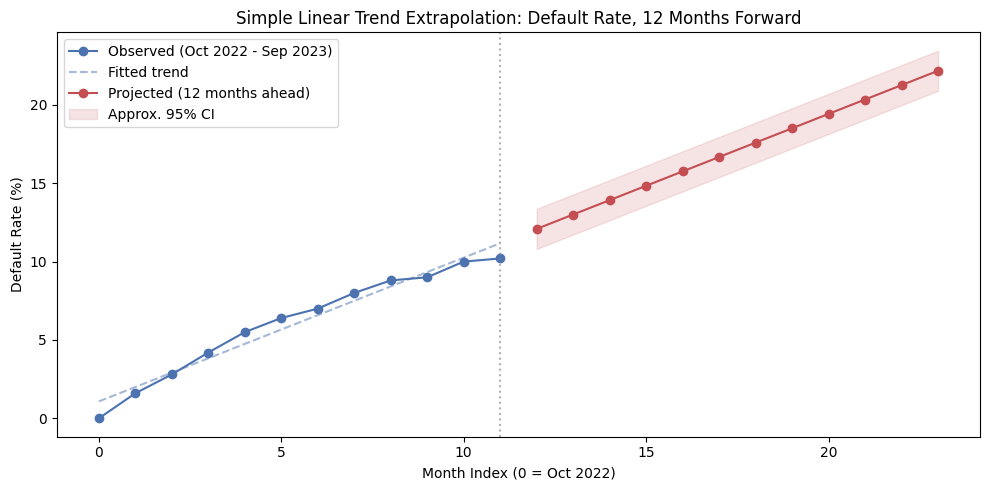

In [8]:
plt.figure(figsize=(10, 5))
# Historical observed data
plt.plot(x,y,marker='o',color='#4C72B0',label='Observed (Oct 2022 - Sep 2023)')
# Fitted line over historical period
plt.plot(x, intercept+slope*x, linestyle='--',color='#4C72B0', alpha=0.5, label='Fitted trend')
# Projected future period
plt.plot(future_x, future_y, marker='o',color='#C44E52',label='Projected (12 months ahead)')
plt.fill_between(future_x, future_y - ci_margin, future_y + ci_margin, 
                  color='#C44E52',alpha=0.15, label='Approx. 95% CI')

plt.axvline(x[-1], color='gray', linestyle=':', alpha=0.6)
plt.xlabel('Month Index (0 = Oct 2022)')
plt.ylabel('Default Rate (%)')
plt.title('Simple Linear Trend Extrapolation: Default Rate, 12 Months Forward')
plt.legend()
plt.tight_layout()
plt.savefig('figures/trend_extrapolation_projection.png', dpi=150)
plt.show()

**Interpretation:** The trend extrapolation projects a 12-month-ahead 
default rate of **22.17%** (95% CI: 20.90%-23.45%), with an extremely high 
R-squared of 0.9658. At first glance this looks like a highly confident 
result, but the high R² needs to be read with caution: this default rate 
series is a **cumulative/stock measure** (as established in notebook 3), and 
cumulative sums of a roughly steady inflow naturally tend to look very 
linear almost by construction. A near-perfect linear fit here reflects this 
mechanical property of the stock measure at least as much as it reflects 
genuine predictive power about future risk direction.

**This method assumes the *average* pace of default rate increase observed 
across the full 12-month history continues unchanged** — and that average 
is pulled upward by the high new-default-formation period in the early 
months (November 2022-February 2023, per notebook 3), which linear 
regression cannot distinguish from a sustained, ongoing trend. This is the 
key limitation of this method for this particular series.

In [9]:
markov_projection=projected_df['4+ (Default)'].iloc[-1] * 100
trend_projection=future_y[-1]

print(f"Markov-chain projected default rate (12 months ahead):     {markov_projection:.2f}%")
print(f"Trend extrapolation projected default rate (12 months ahead): {trend_projection:.2f}%")
print(f"Difference: {abs(markov_projection - trend_projection):.2f} percentage points")

Markov-chain projected default rate (12 months ahead):     18.43%
Trend extrapolation projected default rate (12 months ahead): 22.17%
Difference: 3.74 percentage points


`Difference in two methods`


The two methods I used actually disagree: the Markov approach predicts an 18.4% default rate, while the trend line predicts 22.2%. The trend line looks like a perfect match mathematically, but we shouldn't just trust it blindly. When you add up numbers over time, the chart automatically looks like a straight line that is just how the math works, not proof that it is a better prediction.

The real reason they give different results is that the trend line includes a big spike in defaults from early in the year, even though that spike already faded away by mid-year. The Markov method focuses on where the data stands right now, so I trust it more. However, instead of hiding the disagreement, we should show both methods and explain exactly why they differ. That is much more valuable for management than just picking one.

## Limitations of this forecast

Both methods give a useful estimate, but neither should be treated as a 
guaranteed outcome. A few honest limitations are worth stating clearly:

- **Only 12 months of data.** Both methods are built on just one year of 
  history. That is a short window to base a 12-month-ahead forecast on, and 
  a longer history would make both methods more reliable.

- **Both methods assume the past keeps repeating.** The Markov method 
  assumes customers will keep moving between delinquency stages at the same 
  rates as last year. The trend method assumes the default rate keeps 
  rising at the same average pace as last year. In reality, the bank's own 
  actions (tighter underwriting, new collections efforts) or outside 
  factors (the economy, interest rates) could change this — neither method 
  can see or account for that.

- **The trend method is more exposed to one weakness in particular.** As 
  shown in the reconciliation above, it cannot tell the difference between 
  a temporary early-year spike in new defaults and a genuine ongoing trend 
  — it just averages everything together. This is the main reason it 
  produced a higher, likely less reliable, projection than the Markov method.

- **Neither method uses outside economic information.** Things like 
  unemployment, interest rates, or inflation are not part of either 
  calculation.


## how this forecast could be improved with more data

With more data. a few years, I'd use something like Prophet instead of a straight line, since it can separate genuine trend from seasonality and detect changepoints which would have automatically caught the early-year surge I had to identify manually here. Then maybe I'd make the transition matrix time-varying rather than one blended average, so it reflects whether we're in a calmer or riskier period. And also, I'd build the forecast separately for each behavioural segment, since I already showed Revolvers and Transactors have wildly different risk profiles a single portfolio-level number hides that. And importantly, with more history I could properly validate any of this out-of-time, holding out real future months to check accuracy, which simply isn't possible with only twelve months of data.

## Summary of Task 1.3 findings

**Method 1 — Markov-chain roll-rate projection:** Applying the transition 
matrix from notebook 3 forward 12 months projects the default rate rising 
from **10.20% to 18.43%**. This projection is directly traceable to a 
specific mechanism the weak cure rate from the 2 month past due stage 
onward identified in notebook 3 making it actionable

**Method 2 — Simple trend extrapolation:** A linear regression on the 
12-month default rate series projects **22.17%** (95% CI: 20.90%-23.45%), 
with a very high R square of 0.9658. This high fit because of forecasting a cumulative/stock measure, and should not be read as proof 
of superior accuracy.

**Reconciliation:** The two methods disagree by roughly 3.7 percentage 
points. The trend method's higher estimate is explained by it implicitly 
carrying forward the effect of an early-year default surge (identified in 
notebook 3's new default formation analysis) that had already faded by 
mid-year. The Markov method, grounded in the current state distribution, is 
considered the more credible estimate for this reason — though both are 
presented together, since the disagreement itself, and its explanation, is 
informative for the Bank.

**Limitations:** Both methods rely on only 12 months of data and assume 
historical patterns continue unchanged; neither incorporates macroeconomic 
conditions, which would be the natural next addition in a full ICAAP-style 
stress testing framework.

**Practical conclusion:** Based on current behaviour, the portfolio's 
default rate is likely to be somewhere in the range of **18-22% twelve 
months from now** if no intervention occurs, with the lower end of that 
range considered more likely given the recent deceleration in new default 
formation. The clearest, most evidence-backed action available to the Bank 
is targeted early intervention at the 2 month past due stage, where the 
roll rate analysis shows the majority of accounts currently fail to recover.